Files originally from https://github.com/LucasSilvaFerreira/Perturb_Loader


In [1]:
import mudata as md
import anndata as ad
import numpy as np
import pandas as pd
import perturbvi
import seaborn as sns
import scanpy as sc
import os
import scipy
import pyro
from scipy.stats import norm
import matplotlib.pyplot as plt
import torch

smoke_test = True
# subsample_frac = 1.
# downsample_frac = 1.

# selected_guides = ["ACTG1_TSS|1", "ACTG1_TSS|2", "ACTB_TSS|1", "ACTB_TSS|2"]
# selected_genes = ["ACTG1"]
# selected_guides = ["TMED10_TSS|1", "TMED10_TSS|2"]
# selected_genes = ["TMED10"]
# selected_guides = ["KRT18_TSS|1", "KRT18_TSS|2"]
# selected_genes = ["KRT18"]
data_dir = "../../../Downloads"
adata_file = f"{data_dir}/GasperiniShendure2019_atscale.h5ad"
adata = ad.read_h5ad(adata_file)
adata

/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Global seed set to 0


AnnData object with n_obs × n_vars = 207324 × 13135
    obs: 'sample', 'total_umis', 'Size_Factor', 'gene', 'all_gene', 'barcode', 'read_count', 'umi_count', 'proportion', 'guide_count', 'sample_directory', 'ko_barcode_file', 'id', 'prep_batch', 'within_batch_chip', 'within_chip_lane', 'percent.mito', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo'
    var: 'ensembl_id', 'ncounts', 'ncells'

In [2]:
adata = adata[:,['ACTB', 'ACTG1']]
adata

View of AnnData object with n_obs × n_vars = 207324 × 2
    obs: 'sample', 'total_umis', 'Size_Factor', 'gene', 'all_gene', 'barcode', 'read_count', 'umi_count', 'proportion', 'guide_count', 'sample_directory', 'ko_barcode_file', 'id', 'prep_batch', 'within_batch_chip', 'within_chip_lane', 'percent.mito', 'tissue_type', 'cell_line', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo'
    var: 'ensembl_id', 'ncounts', 'ncells'

In [3]:
adata.obs

,sample,total_umis,Size_Factor,gene,all_gene,barcode,read_count,umi_count,proportion,guide_count,...,disease,perturbation_type,celltype,organism,perturbation,nperts,ngenes,ncounts,percent_mito,percent_ribo
AAACCTGAGAGGTACC,1A_1_SI-GA-E2,17572,1.009682,chr10.845_top_two_chr1.11183_top_two_chr1.1129...,chr10.845_top_two_chr1.11183_top_two_chr1.1129...,AGAAAGCTCCTCCAGTTCAC_TGATCGCTTTGACTGTGACA_ACAA...,14135.0,964.0,0.969819,67.0,...,chronic myelogenous leukemia,CRISPR,lymphoblasts,human,chr10.845_top_two_chr1.11183_top_two_chr1.1129...,195,3549,17566.0,0.0,30.507799
AAACCTGAGTCAATAG,1A_1_SI-GA-E2,8923,0.939677,chr1.12695_top_two_chr11.3294_top_two_chr1.679...,chr1.12695_top_two_chr11.3294_top_two_chr1.679...,GTAGAGCCTCCAGAACTGTG_AGGTTTATCCAGATGAACTG_CATC...,4329.0,293.0,0.844380,26.0,...,chronic myelogenous leukemia,CRISPR,lymphoblasts,human,chr1.12695_top_two_chr11.3294_top_two_chr1.679...,68,2543,8917.0,0.0,28.955927
AAACCTGCAAACAACA,1A_1_SI-GA-E2,14637,0.990803,ALDH1A2_TSS_BRI3_TSS_chr10.1918_top_two_chr10....,ALDH1A2_TSS_BRI3_TSS_chr10.1918_top_two_chr10....,CCAAGGCGTCCTCAGACCAG_AGCTCCAGGAAGGACCCCCG_TCAC...,12362.0,884.0,0.950538,61.0,...,chronic myelogenous leukemia,CRISPR,lymphoblasts,human,ALDH1A2_BRI3_chr10.1918_top_two_chr10.350_top_...,167,3191,14626.0,0.0,26.548612
AAACCTGCACTTCTGC,1A_1_SI-GA-E2,22798,1.036578,C16orf91_TSS_chr1.11332_top_two_chr1.1933_top_...,C16orf91_TSS_chr1.11332_top_two_chr1.1933_top_...,GGCGTCAGTCGAGGAGTCAG_GCCAGCACTTCAGCTCACCG_GCTG...,7459.0,544.0,0.939551,39.0,...,chronic myelogenous leukemia,CRISPR,lymphoblasts,human,C16orf91_chr1.11332_top_two_chr1.1933_top_two_...,109,4539,22783.0,0.0,20.616249
AAACCTGCATGTAGTC,1A_1_SI-GA-E2,10136,0.952844,chr10.185_top_two_chr10.484_top_two_chr11.4167...,chr10.185_top_two_chr10.484_top_two_chr11.4167...,ATAAGGCACTCACATCCACC_GCTTGTCCCTAACACTCAGA_GGGC...,14831.0,1054.0,0.959927,37.0,...,chronic myelogenous leukemia,CRISPR,lymphoblasts,human,chr10.185_top_two_chr10.484_top_two_chr11.4167...,107,2605,10124.0,0.0,32.418017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCAGTACCTACA,2B_8_SI-GA-H9,17938,1.011811,BRIX1_TSS_chr10.2059_top_two_chr10.350_top_two...,BRIX1_TSS_chr10.2059_top_two_chr10.350_top_two...,AGGAGGCCAAGAGCGCGGGG_TGATTGAAGGAGGCTCCCCA_GGTA...,4570.0,394.0,0.856522,31.0,...,chronic myelogenous leukemia,CRISPR,lymphoblasts,human,BRIX1_chr10.2059_top_two_chr10.350_top_two_chr...,85,3451,17934.0,0.0,31.733021
TTTGTCAGTATCACCA-1,2B_8_SI-GA-H9,16543,1.003448,chr10.221_top_two_chr11.3853_top_two_chr11.498...,chr10.221_top_two_chr11.3853_top_two_chr11.498...,CCTGCAACTGTCTATGGCCT_TCAGTGGGTGAGTCTTCAGG_TGAG...,4311.0,387.0,0.861915,33.0,...,chronic myelogenous leukemia,CRISPR,lymphoblasts,human,chr10.221_top_two_chr11.3853_top_two_chr11.498...,92,3693,16542.0,0.0,24.694716
TTTGTCAGTTCAGACT-1,2B_8_SI-GA-H9,15009,0.993396,chr12.3400_top_two_chr4.1281_second_two_ID3_TSS,chr12.3400_top_two_chr4.1281_second_two_ID3_TSS,CCAGTTGCTAGGCAGGACAG_CTTTCAGGCAGGAATCTGAG_TGGT...,669.0,57.0,0.876923,3.0,...,chronic myelogenous leukemia,CRISPR,lymphoblasts,human,chr12.3400_top_two_chr4.1281_second_two_ID3,7,3162,14992.0,0.0,32.123799
TTTGTCAGTTCTGTTT,2B_8_SI-GA-H9,5149,0.882878,chr7.1014_top_two,chr7.1014_top_two,CACCCCCCAGAGATAAGAGA,77.0,7.0,0.086420,1.0,...,chronic myelogenous leukemia,CRISPR,lymphoblasts,human,chr7.1014_top_two,3,1392,5149.0,0.0,35.074772


## Convert barcode observations to sparse matrix

Text(0.5, 1.0, 'barcode_counts')

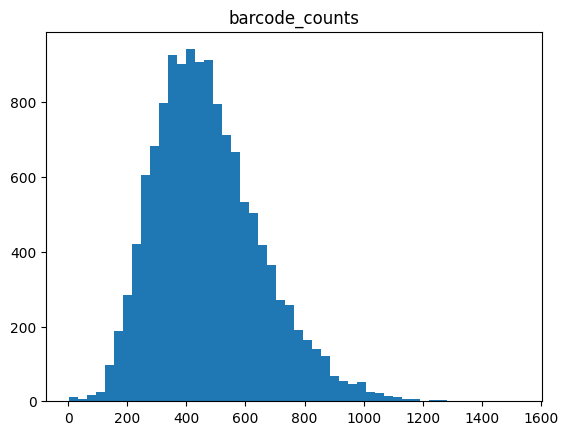

In [4]:
from collections import Counter
import scipy.sparse as sp

c = Counter()
split_bcs = adata.obs['barcode'].str.split('_', regex=False)

for bc_list in split_bcs:
    c.update(bc_list)
plt.hist(c.values(), bins=50)
# plt.axvline(x=cutoff, linestyle="dashed")
plt.title("barcode_counts")


In [5]:
# first pass: count barcodes
bc_counts = Counter()
split_bcs = adata.obs['barcode'].str.split('_', regex=False)
for bc_list in split_bcs:
    bc_counts.update(bc_list)
bc_dict = {k: i for i, k in enumerate(bc_counts)}
total_counts = sum(bc_counts.values())

In [6]:
# second pass: construct sparse array
indices = [] # barcode indices
data = [] # barcode counts
indptr = [0] # column indices for row i are stored in indices[indptr[i]:indptr[i+1]]
for i, bc_list in enumerate(split_bcs):
    bcs_i = Counter(bc_list)
    indptr.append(indptr[i] + len(bcs_i))
    indices+=[bc_dict[bc] for bc in bcs_i]
    data+=list(bcs_i.values())
assert len(indices) == len(data)

adata.obsm['grna'] = sp.csr_matrix((data, indices, indptr))
assert adata.obsm['grna'].sum() == total_counts

<Axes: xlabel='umi_count', ylabel='Count'>

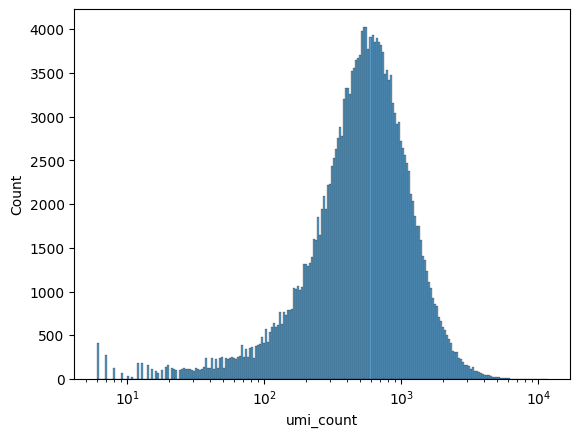

In [7]:
sns.histplot(adata.obs['umi_count'], log_scale=[True, False])

In [8]:
adata = adata[adata.obs['umi_count']>100,:]

In [9]:
perturbvi.PERTURBVI.setup_anndata(
    adata,
    'grna',
    batch_key="prep_batch",
    library_size_key="umi_count",
    continuous_covariates_keys=["percent_mito", "percent_ribo"],
    # size_factor_key="Size_Factor",
)

model = perturbvi.PERTURBVI(adata)
model.view_anndata_setup()


INFO     Generating sequential column names                                                                        


/Users/ljb80/Projects/perturbvi/src/perturbvi/_model.py:96: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["_ind_x"] = np.arange(len(adata))
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/scvi/data/_utils.py:121: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  warnings.warn(


Anndata setup with scvi-tools version 0.20.1.

Setup via `PERTURBVI.setup_anndata` with arguments:

{
│   'perturbation_key': 'grna',
│   'layer': None,
│   'batch_key': 'prep_batch',
│   'size_factor_key': None,
│   'continuous_covariates_keys': ['percent_mito', 'percent_ribo'],
│   'library_size_key': 'umi_count'
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃    Summary Stat Key     ┃ Value  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│         n_batch         │   2    │
│         n_cells         │ 193951 │
│ n_extra_continuous_covs │   2    │
│     n_perturbations     │ 13187  │
│         n_vars          │   2    │
└─────────────────────────┴────────┘

                            Data Registry                            
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃     Registry Key      ┃            scvi-tools Location            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X           │                  adata.X                  │
│         batch         │         adata.obs['_scvi_batch']          │
│ extra_continuous_covs │ adata.obsm['_scvi_extra_continuous_covs'] │
│         ind_x         │            adata.obs['_ind_x']            │
│     perturbations     │            adata.obsm['grna']             │
│      size_factor      │         adata.obs['_size_factor']         │
└───────────────────────┴───────────────────────────────────────────┘

                      batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location     ┃  Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['prep_batch'] │ prep_batch_1 │          0          │
│                         │ prep_batch_2 │          1          │
└─────────────────────────┴──────────────┴─────────────────────┘

 extra_continuous_covs State 
          Registry           
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['percent_mito'] │
│ adata.obs['percent_ribo'] │
└───────────────────────────┘

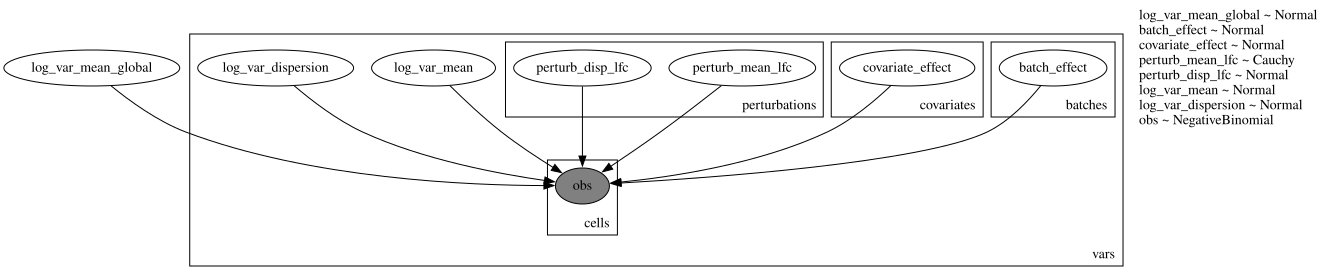

In [10]:
# requires graphviz to be installed
model.render_model()

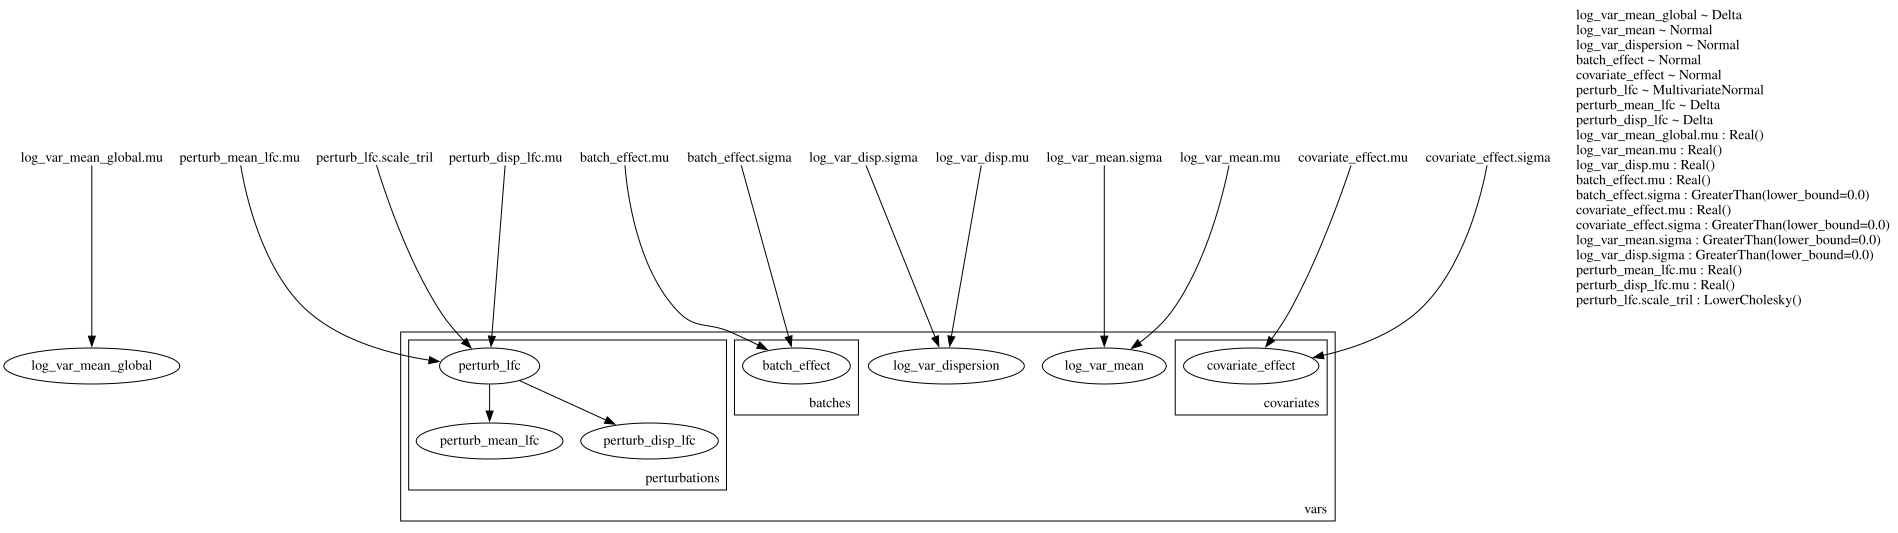

In [11]:
pyro.clear_param_store()

model.render_guide()

## Model training

We can start out with a really high learning rate, then decrease the learning rate to fine-tune


In [14]:
# burn-in
# if smoke_test:
    # model.train(10, lr=0.1, batch_size=1024)
# else:
model.train(20, lr=0.01, batch_size=512)

GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/configuration_validator.py:106: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")


Epoch 10/20:  45%|████▌     | 9/20 [02:12<02:41, 14.73s/it, v_num=1, elbo_train=1.55e+6]

/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/call.py:48: UserWarning: Detected KeyboardInterrupt, attempting graceful shutdown...
  rank_zero_warn("Detected KeyboardInterrupt, attempting graceful shutdown...")


In [15]:
# fine-tuning
model.train(20, lr=1e-3, batch_size=8192)


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/setup.py:201: UserWarning: MPS available but not used. Set `accelerator` and `devices` using `Trainer(accelerator='mps', devices=1)`.
  rank_zero_warn(
/Users/ljb80/Projects/perturbvi/.hatch/perturbvi/lib/python3.10/site-packages/pytorch_lightning/trainer/configuration_validator.py:106: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")


Epoch 20/20: 100%|██████████| 20/20 [02:08<00:00,  6.44s/it, v_num=1, elbo_train=1.43e+6]

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 20/20: 100%|██████████| 20/20 [02:08<00:00,  6.42s/it, v_num=1, elbo_train=1.43e+6]


In [16]:
for k, v in pyro.get_param_store().items():
    print(k, v.shape)
    if sum(v.shape) <= 1:
        print(v)


log_var_mean_global.mu torch.Size([1])
tensor([0.7216], requires_grad=True)
log_var_mean.mu torch.Size([2])
log_var_disp.mu torch.Size([2])
batch_effect.mu torch.Size([2, 2])
batch_effect.sigma torch.Size([2, 2])
covariate_effect.mu torch.Size([3, 2])
covariate_effect.sigma torch.Size([3, 2])
log_var_mean.sigma torch.Size([2])
log_var_disp.sigma torch.Size([2])
perturb_mean_lfc.mu torch.Size([13187, 2])
perturb_disp_lfc.mu torch.Size([13187, 2])
perturb_lfc.scale_tril torch.Size([13187, 2, 2, 2])


In [17]:
# plt.hist(pyro.get_param_store()["library_size_effect.mu"].cpu().detach().numpy())


In [18]:
%load_ext autoreload
%autoreload 2

selected_genes = adata.var_names
selected_guides = list(bc_dict.keys())
# lfc_threshold = -0.1 # ~ at least 10% upreg
lfc_threshold = 0 # nonzero knockdown
# gene_index=45

# scale_factor = 0.01
perturb_mean_lfc_mu = pyro.get_param_store()['perturb_mean_lfc.mu'].detach().cpu().numpy()
perturb_disp_lfc_mu = pyro.get_param_store()['perturb_disp_lfc.mu'].detach().cpu().numpy()
lfc_cov_tril = pyro.get_param_store()['perturb_lfc.scale_tril']
lfc_cov = lfc_cov_tril @ lfc_cov_tril.transpose(dim0=-1, dim1=-2)
perturb_mean_lfc_sigma = lfc_cov[...,0,0].sqrt().detach().cpu().numpy()
perturb_disp_lfc_sigma = lfc_cov[...,1,1].sqrt().detach().cpu().numpy()
assert perturb_mean_lfc_mu.shape == perturb_mean_lfc_sigma.shape
perturb_z_scores = perturb_mean_lfc_mu/perturb_mean_lfc_sigma
perturb_p_vals = norm.sf(lfc_threshold, loc=perturb_mean_lfc_mu, scale=perturb_mean_lfc_sigma)

def make_long_df(mat, value_name):
    return (
        pd.DataFrame(data=mat, columns=selected_genes, index=selected_guides)
        .melt(var_name="gene", value_name=value_name, ignore_index=False)
        .reset_index(names="guide")
    )
mu_df = make_long_df(perturb_mean_lfc_mu, "mu")
z_df = make_long_df(perturb_z_scores, "z_value")
p_df = make_long_df(perturb_p_vals, "p_value")


In [19]:
gasperini_guides = pd.read_excel("../../../Data/gasperini_atscale/mmc2.xlsx", sheet_name=1)
max_grna_length=19
gasperini_guides['guide'] = gasperini_guides['Spacer'].str.slice(0, 19)
gasperini_guides['guide'].str.len()

Epoch 10/20:  45%|████▌     | 9/20 [10:46<13:09, 71.79s/it, v_num=1, elbo_train=1.55e+6]


0        19
1        19
2        19
3        19
4        19
         ..
13184    19
13185    19
13186    19
13187    19
13188    19
Name: guide, Length: 13189, dtype: int64

In [20]:
scpower_df = pd.merge(z_df, p_df)

# if not smoke_test:
#     scpower_df.to_csv("~/Downloads/all_results.csv")
# significant_results = scpower_df.query("p_value < 1e-8")
# significant_results['element'] = significant_results['guide'].str.split("|", expand=True)[0]
# significant_results
scpower_df.sort_values('z_value').head(10)
scpower_df['guide'] = scpower_df['guide'].str.slice(0, 19)
scpower_df
# guide_gene_pairs = significant_results.groupby(['element','gene'])['guide'].count()
# guide_gene_pairs=guide_gene_pairs[guide_gene_pairs==2]
# guide_gene_pairs.to_excel("~/Downloads/guide_pairs.xlsx")
# # guide_gene_pairs.index
# scpower_df.query("p_value < 1e-3").to_excel("~/Downloads/significant_results.xlsx")
# significant_results['guide'].str.split("_", expand=True)[0]
# significant_results.head(1000).to_excel("~/Downloads/significant_results.xlsx")

,guide,gene,z_value,p_value
0,AGAAAGCTCCTCCAGTTCA,ACTB,-0.249337,0.401550
1,TGATCGCTTTGACTGTGAC,ACTB,-1.344472,0.089398
2,ACAATAAAGAACAGAACAC,ACTB,-0.548005,0.291844
3,GTAAATTGAGACCTCAGGA,ACTB,0.399404,0.655202
4,TCTTCCCCCCACCAATAAC,ACTB,-1.591698,0.055726
...,...,...,...,...
26369,TCCTCCCCACGGCCACCAG,ACTG1,2.607902,0.995445
26370,TCCTTCCCCTCAGTACACC,ACTG1,-0.061127,0.475629
26371,ACATGCTGTTTCCAGAGCA,ACTG1,0.032947,0.513142
26372,CTTCTTCCACAAGAAGACA,ACTG1,-0.690076,0.245073


In [27]:
merge_df = (
    scpower_df.merge(gasperini_guides, how="left", indicator=True)
    .sort_values("z_value")
    .assign(is_target=lambda x: x["gene"] == x["Target_Site"])
)
merge_df.tail(20)
# anti_join = outer_join[~(outer_join._merge == "both")].drop("_merge", axis=1)
# anti_join


,guide,gene,z_value,p_value,Spacer,Target_Site,chr.candidate_enhancer,start.candidate_enhancer,stop.candidate_enhancer,Category,_merge,is_target
3324,AGTTGTGTTGTGCCAATGG,ACTB,4.708758,0.999999,AGTTGTGTTGTGCCAATGG,ZNHIT1,NaN,NaN,NaN,TSS,both,False
25486,CGCTCCCGCCAAGCACCGG,ACTG1,4.773547,0.999999,CGCTCCCGCCAAGCACCGG,PCNA,NaN,NaN,NaN,TSS,both,False
14833,GCAGCAGTGTCGACGGCAG,ACTG1,4.857121,0.999999,GCAGCAGTGTCGACGGCAG,U2AF1,NaN,NaN,NaN,TSS,both,False
16563,GCACTCCTCTAAAGGAGCT,ACTG1,4.952008,1.000000,GCACTCCTCTAAAGGAGCTT,chr6.1231,chr6,27204897.0,27205576.0,candidate_enhancer:picked_by_model_built_from_...,both,False
3020,CACCGGCAGAGAAACGCGA,ACTB,5.276645,1.000000,CACCGGCAGAGAAACGCGA,ACTG1,NaN,NaN,NaN,TSS,both,False
16448,AGACACCATAAGCATATGG,ACTG1,5.431485,1.000000,AGACACCATAAGCATATGGC,chr16.1085,chr16,9085779.0,9086156.0,candidate_enhancer:picked_by_model_built_from_...,both,False
4948,CAGGGGTGTGGAAACTTAC,ACTB,5.481182,1.000000,CAGGGGTGTGGAAACTTAC,CCDC86,NaN,NaN,NaN,TSS,both,False
5814,GATGGGTTGGTAGCAGACA,ACTB,5.513101,1.000000,GATGGGTTGGTAGCAGACA,RABGGTB,NaN,NaN,NaN,TSS,both,False
1822,GGCCTGACGGAGAAGACGC,ACTB,5.617148,1.000000,GGCCTGACGGAGAAGACGCG,chrX.952,chrX,48641145.0,48641725.0,candidate_enhancer:repeated_from_pilot:top_gRN...,both,False
14356,GCTGTGGCTCAGCCTCCCC,ACTG1,5.778176,1.000000,GCTGTGGCTCAGCCTCCCCA,chr11.1735,chr11,33966182.0,33966805.0,candidate_enhancer:repeated_from_pilot:top_gRN...,both,False


In [22]:
print(selected_genes)
pyro.get_param_store()['covariate_effect.mu']
# pyro.get_param_store()['covariate_effect.sigma']


Index(['ACTB', 'ACTG1'], dtype='object', name='gene_symbol')


tensor([[-0.0356, -0.0215],
        [-0.0582, -0.0089],
        [-0.6014, -0.5646]], requires_grad=True)

[]

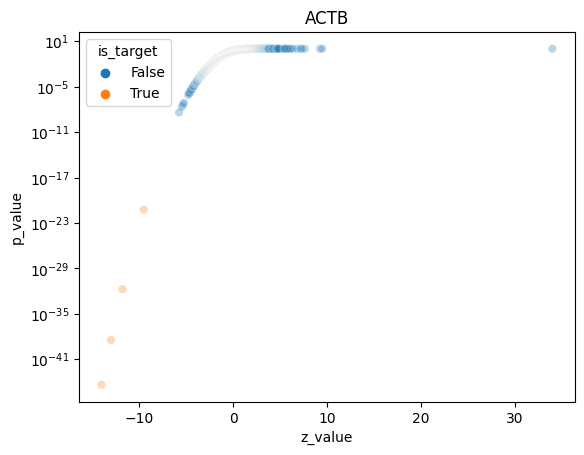

In [23]:
sns.scatterplot(
    merge_df,
    hue="is_target",
    x="z_value",
    y="p_value",
    alpha=0.3
)
if smoke_test:
    plt.title(selected_genes[0])

plt.semilogy()
# significant_results.groupby("guide").count()['gene'].sort_values().tail(20)
# significant_results.to_excel("significant_results.xlsx")
# # perturb_z_scores[:,gene_index].detach().cpu().numpy()
# z_df = pd.DataFrame({'z_score': perturb_z_scores[:,gene_index],
#                     'mean_mu': perturb_mean_lfc_mu[:,gene_index],
#                     'disp_mu': perturb_disp_lfc_mu[:,gene_index],
#                     'mu_p_val': perturb_p_vals[:,gene_index],
#                     'grna': mdata_subset['grna'].var_names,})
# # z_df.hist('mu_p_val', bins=100)
# names[gene_index])
# print(z_df.sort_values('mu_p_val', ascending=True).reset_index(drop=True).head(20))
